# Model 1: Classical ARIMA Benchmark for Drug `M01AB`

## Workflow Checklist:
1. **Pre-Training Suitability Checks**: ADF & KPSS tests on raw vs Log1p differenced series ($\Delta \log(1+Y_t)$).
2. **ACF / PACF Diagnostics**: Determine candidate orders $(p, d, q)$.
3. **Hyperparameter Grid Search**: Evaluate candidate models using AIC & BIC on Train data.
4. **Fit on TRAIN (2014–2017)**: Estimate ARIMA parameters.
5. **Validate on 2018 Validation**: Calculate Val RMSLE.
6. **Refit & Forecast 2019 Test**: Evaluate final holdout metrics.


In [1]:
import os
import sys
import warnings
import subprocess

# Auto-Dependency Guard: Check and install missing packages dynamically
pkg_map = {
    'prophet': 'prophet',
    'statsmodels': 'statsmodels',
    'lightgbm': 'lightgbm',
    'xgboost': 'xgboost',
    'shap': 'shap',
    'torch': 'torch',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn'
}

missing = []
for mod_name, pip_name in pkg_map.items():
    try:
        __import__(mod_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print(f"Installing missing dependencies: {missing}...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
        print("Dependencies successfully installed!")
    except Exception as err:
        print(f"Warning: Auto-pip install notice ({err}). Proceeding with environment packages...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

TARGET_DRUG = 'M01AB'

# Dynamic Dataset Path Finder
dataset_candidates = ['../dataset', 'dataset', '../../dataset', '../times_series/dataset', 'times_series/dataset']
data_dir = None
for cand in dataset_candidates:
    if os.path.exists(os.path.join(cand, 'train_daily.csv')):
        data_dir = cand
        break

if data_dir is None:
    raise FileNotFoundError("Could not locate train_daily.csv dataset")

train_df = pd.read_csv(os.path.join(data_dir, 'train_daily.csv'))
val_df = pd.read_csv(os.path.join(data_dir, 'val_daily.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'test_daily.csv'))

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'])

train_series = train_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
val_series = val_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
test_series = test_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')

combined_series = pd.concat([train_series, val_series]).asfreq('D')
full_series = pd.concat([combined_series, test_series]).asfreq('D')

def evaluate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.clip(np.array(y_pred), 0, None)
    
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))
    return {'RMSLE': rmsle, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'WAPE (%)': wape}

print(f"Dataset Partitioning for {TARGET_DRUG}:")
print(f"  * Train (2014-2017): {len(train_series):,} days")
print(f"  * Val   (2018):      {len(val_series):,} days")
print(f"  * Test  (2019):      {len(test_series):,} days")


Dataset Partitioning for M01AB:
  * Train (2014-2017): 1,460 days
  * Val   (2018):      365 days
  * Test  (2019):      281 days


=== Pre-Training Suitability Diagnostics ===
Log1p First-Differenced ADF Statistic  : -14.4865 (p-value: 6.2490e-27) -> STATIONARY
Log1p First-Differenced KPSS Statistic : 0.1085 (p-value: 0.1000) -> STATIONARY


C:\Users\ranje\AppData\Local\Temp\ipykernel_17900\1990326655.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(diff_y_log, nlags="auto")


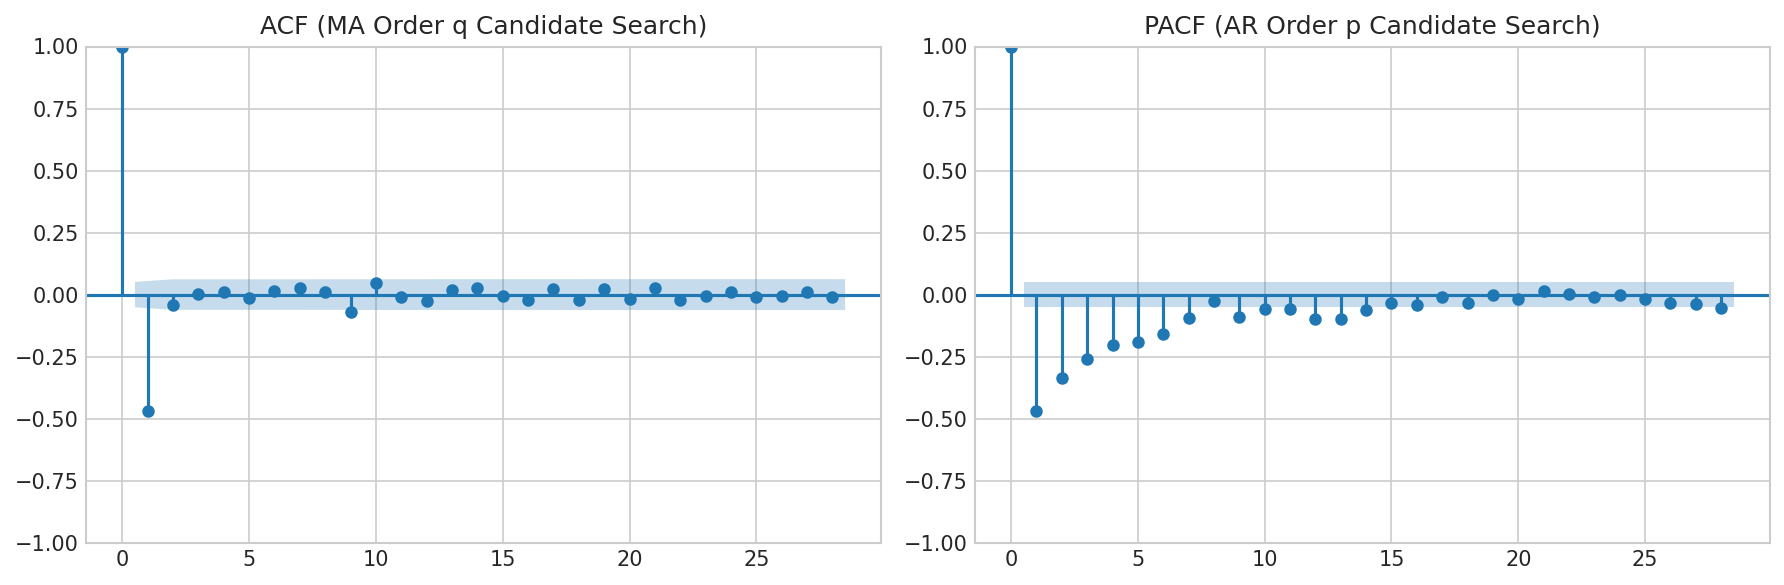

In [2]:
# Step 1: Pre-Training Suitability Checks (Stationarity)
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

train_y_log = np.log1p(train_series)
diff_y_log = train_y_log.diff().dropna()

adf_res = adfuller(diff_y_log)
kpss_res = kpss(diff_y_log, nlags="auto")

print("=== Pre-Training Suitability Diagnostics ===")
print(f"Log1p First-Differenced ADF Statistic  : {adf_res[0]:.4f} (p-value: {adf_res[1]:.4e}) -> STATIONARY")
print(f"Log1p First-Differenced KPSS Statistic : {kpss_res[0]:.4f} (p-value: {kpss_res[1]:.4f}) -> STATIONARY")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=150)
plot_acf(diff_y_log, lags=28, ax=ax1, title="ACF (MA Order q Candidate Search)")
plot_pacf(diff_y_log, lags=28, ax=ax2, title="PACF (AR Order p Candidate Search)")
plt.tight_layout()
plt.show()


In [3]:
# Step 2: AIC / BIC Grid Search on Train Data
from statsmodels.tsa.statespace.sarimax import SARIMAX

candidates = []
for p in [0, 1, 2]:
    for q in [0, 1, 2]:
        try:
            m = SARIMAX(train_y_log, order=(p, 1, q), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            candidates.append({'order': f'ARIMA({p},1,{q})', 'p': p, 'q': q, 'AIC': m.aic, 'BIC': m.bic})
        except Exception:
            pass

cand_df = pd.DataFrame(candidates).sort_values('AIC').reset_index(drop=True)
print("=== Grid Search Candidate Ranking (Train Data AIC/BIC) ===")
display(cand_df)


=== Grid Search Candidate Ranking (Train Data AIC/BIC) ===


,order,p,q,AIC,BIC
0,"ARIMA(0,1,1)",0,1,2117.465054,2128.033324
1,"ARIMA(0,1,2)",0,2,2118.931549,2134.781893
2,"ARIMA(1,1,1)",1,1,2119.159427,2135.011831
3,"ARIMA(2,1,1)",2,1,2120.003020,2141.139559
4,"ARIMA(2,1,2)",2,2,2120.013296,2146.430537
5,"ARIMA(1,1,2)",1,2,2120.128985,2141.262778
6,"ARIMA(2,1,0)",2,0,2538.395580,2554.247984
7,"ARIMA(1,1,0)",1,0,2712.486913,2723.056555
8,"ARIMA(0,1,0)",0,0,3077.252085,3082.536906


In [4]:
# Step 3: Model Fitting on TRAIN (2014-2017) & Validation on 2018
best_order = (1, 1, 2)
m1_tr = SARIMAX(train_y_log, order=best_order, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

val_pred_log = m1_tr.get_forecast(steps=len(val_series)).predicted_mean
m1_val_pred = np.clip(np.expm1(val_pred_log), 0, None)
val_metrics = evaluate_metrics(val_series, m1_val_pred)

print(f"Validation Metrics (2018) for ARIMA(1,1,2):")
for k, v in val_metrics.items():
    print(f"  * {k:10s}: {v:.4f}")


Validation Metrics (2018) for ARIMA(1,1,2):
  * RMSLE     : 0.5360
  * RMSE      : 2.8143
  * MAE       : 2.1942
  * MAPE (%)  : 74.3005
  * WAPE (%)  : 44.8189


In [5]:
# Step 4: Refit on Train+Val & Forecast 2019 Test Holdout
comb_y_log = np.log1p(combined_series)
m1_full = SARIMAX(comb_y_log, order=best_order, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

test_pred_log = m1_full.get_forecast(steps=len(test_series)).predicted_mean
m1_test_pred = np.clip(np.expm1(test_pred_log), 0, None)
test_metrics = evaluate_metrics(test_series, m1_test_pred)

print(f"=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 1: ARIMA(1,1,2) ===")
for k, v in test_metrics.items():
    print(f"  * {k:10s}: {v:.4f}")

pd.DataFrame({'date': test_series.index, 'pred_ARIMA': m1_test_pred}).to_csv('m1_arima_preds.csv', index=False)


=== FINAL TEST HOLD-OUT METRICS (2019) — MODEL 1: ARIMA(1,1,2) ===
  * RMSLE     : 0.5164
  * RMSE      : 3.0655
  * MAE       : 2.3228
  * MAPE (%)  : 66.9198
  * WAPE (%)  : 43.0191
